In [1]:
import os
import json
import numpy as np
import kagglehub
from sklearn.preprocessing import LabelEncoder
from tqdm.notebook import tqdm
import math
from datetime import datetime
import matplotlib.pyplot as plt

In [2]:
def setup_paths():
    yolo_path = kagglehub.dataset_download("yasserouzzine2/lstm-boxing-datasetunlabeled")
    print("Path to YOLO dataset:", yolo_path)

    boxing_path = kagglehub.dataset_download("piotrstefaskiue/olympic-boxing-punch-classification-video-dataset")
    print("Path to boxing dataset:", boxing_path)

    return yolo_path, boxing_path

def process_annotations(boxing_path):
    """Process annotation files to create frame-to-label mapping"""
    annotations_map = {}
    action_stats = {}

    print("Processing annotation files...")
    for root, dirs, files in os.walk(boxing_path):
        if 'annotations.json' in files:
            video_name = os.path.basename(root)
            print(f"\nProcessing {video_name}")

            with open(os.path.join(root, 'annotations.json'), 'r') as f:
                try:
                    annotation_data = json.load(f)
                    frame_labels = {}
                    action_counts = {}

                    for annotation in annotation_data:
                        if 'tracks' in annotation:
                            for track in annotation['tracks']:
                                label = track.get('label')
                                shapes = track.get('shapes', [])

                                action_counts[label] = action_counts.get(label, 0) + 1

                                valid_shapes = [s for s in shapes if not s.get('outside', False)]

                                if valid_shapes:
                                    start_frame = valid_shapes[0]['frame']
                                    end_frame = valid_shapes[-1]['frame']
                                    duration = end_frame - start_frame + 1

                                    for i, shape in enumerate(valid_shapes):
                                        frame_idx = shape['frame']
                                        frame_labels[frame_idx] = {
                                            'label': label,
                                            'start_frame': start_frame,
                                            'end_frame': end_frame,
                                            'duration': duration,
                                            'progress': i / len(valid_shapes),
                                            'bbox': shape['points']
                                        }

                    if frame_labels:
                        print(f"Found {len(frame_labels)} labeled frames")
                        print("Action distribution:")
                        for action, count in action_counts.items():
                            print(f"- {action}: {count}")

                        annotations_map[video_name] = frame_labels
                        action_stats[video_name] = action_counts

                except Exception as e:
                    print(f"Error processing {video_name}: {str(e)}")

    return annotations_map, action_stats

In [3]:
def normalize_video_name(name):
    """Extract task number and video number from filename"""
    numbers = ''.join(filter(str.isdigit, name))
    if len(numbers) >= 6:
        task_num = numbers[:1]
        video_num = numbers[1:]
        return f"task_kam{task_num}_gh{video_num}"
    return name

def match_video_names(yolo_name, annotation_names):
    """Find matching annotation name for YOLO video name"""
    normalized_yolo = normalize_video_name(yolo_name)

    if normalized_yolo in annotation_names:
        return normalized_yolo

    yolo_numbers = ''.join(filter(str.isdigit, yolo_name))
    for ann_name in annotation_names:
        ann_numbers = ''.join(filter(str.isdigit, ann_name))
        if yolo_numbers in ann_numbers or ann_numbers in yolo_numbers:
            return ann_name

    return None

def calculate_enhanced_motion_metrics(current_frame, prev_frame):
    """
    Calculate boxing motion metrics using YOLO keypoint indices mapping:
    0: Nose          5: Left Shoulder   10: Right Wrist   15: Left Ankle
    1: Left Eye      6: Right Shoulder  11: Left Hip      16: Right Ankle
    2: Right Eye     7: Left Elbow      12: Right Hip
    3: Left Ear      8: Right Elbow     13: Left Knee
    4: Right Ear     9: Left Wrist      14: Right Knee
    """
    metrics = {
        'movement': {
            'speed': 0.0,
            'distance': 0.0
        },
        'boxing_specific': {
            'left_arm_extension': 0.0,
            'right_arm_extension': 0.0,
            'power_index': 0.0,
            'guard_height': 0.0
        },
        'pose': {
            'body_alignment': 0.0,
            'stance_width': 0.0
        }
    }
    
    if current_frame is None or prev_frame is None:
        return metrics
        
    try:
        # Reshape keypoints to (17, 3) format for easier access
        current_keypoints = current_frame[4:].reshape(-1, 3)  # Skip bbox coordinates
        prev_keypoints = prev_frame[4:].reshape(-1, 3)
        
        # Helper function to check if keypoint is valid (confidence > threshold)
        def is_valid_keypoint(kp, threshold=0.3):
            return kp[2] > threshold  # Index 2 is confidence score
            
        # Calculate movement metrics
        if is_valid_keypoint(current_keypoints[0]) and is_valid_keypoint(prev_keypoints[0]):
            # Use nose keypoint for overall movement
            displacement = current_keypoints[0, :2] - prev_keypoints[0, :2]
            distance = np.linalg.norm(displacement)
            metrics['movement']['distance'] = float(distance)
            metrics['movement']['speed'] = float(distance * 50)  # Assuming 50 FPS
            
        # Calculate boxing-specific metrics
        # Left arm extension (shoulder to wrist)
        if all(is_valid_keypoint(current_keypoints[i]) for i in [5, 9]):  # Left shoulder to left wrist
            left_extension = np.linalg.norm(
                current_keypoints[9, :2] - current_keypoints[5, :2]
            )
            metrics['boxing_specific']['left_arm_extension'] = float(left_extension)
            
        # Right arm extension (shoulder to wrist)
        if all(is_valid_keypoint(current_keypoints[i]) for i in [6, 10]):  # Right shoulder to right wrist
            right_extension = np.linalg.norm(
                current_keypoints[10, :2] - current_keypoints[6, :2]
            )
            metrics['boxing_specific']['right_arm_extension'] = float(right_extension)
            
        # Guard height (average wrist height relative to face)
        if all(is_valid_keypoint(current_keypoints[i]) for i in [0, 9, 10]):  # Nose and wrists
            wrists_height = (current_keypoints[9, 1] + current_keypoints[10, 1]) / 2
            face_height = current_keypoints[0, 1]
            metrics['boxing_specific']['guard_height'] = float(wrists_height - face_height)
            
        # Power index (combination of extension and speed)
        max_extension = max(
            metrics['boxing_specific']['left_arm_extension'],
            metrics['boxing_specific']['right_arm_extension']
        )
        metrics['boxing_specific']['power_index'] = float(max_extension * metrics['movement']['speed'])
        
        # Calculate pose metrics
        # Body alignment (angle between shoulders and hips)
        if all(is_valid_keypoint(current_keypoints[i]) for i in [5, 6, 11, 12]):
            shoulder_vector = current_keypoints[6, :2] - current_keypoints[5, :2]
            hip_vector = current_keypoints[12, :2] - current_keypoints[11, :2]
            
            if not np.all(shoulder_vector == 0) and not np.all(hip_vector == 0):
                dot_product = np.dot(shoulder_vector, hip_vector)
                norms = np.linalg.norm(shoulder_vector) * np.linalg.norm(hip_vector)
                metrics['pose']['body_alignment'] = float(abs(dot_product / (norms + 1e-8)))
                
        # Stance width (distance between ankles)
        if all(is_valid_keypoint(current_keypoints[i]) for i in [15, 16]):
            metrics['pose']['stance_width'] = float(
                np.linalg.norm(current_keypoints[16, :2] - current_keypoints[15, :2])
            )
            
    except Exception as e:
        print(f"Error calculating metrics: {str(e)}")
        
    return metrics

def extract_video_numbers(name):
    """Extract task and video numbers from name"""
    numbers = ''.join(filter(str.isdigit, name))
    return numbers

def get_matching_annotation_name(yolo_name, annotation_names):
    """Match YOLO filename with corresponding annotation name"""
    yolo_numbers = extract_video_numbers(yolo_name)

    # Print debug info
    print(f"\nMatching video name: {yolo_name}")
    print(f"Extracted numbers: {yolo_numbers}")

    for ann_name in annotation_names:
        ann_numbers = extract_video_numbers(ann_name)
        if yolo_numbers == ann_numbers or yolo_numbers in ann_numbers:
            print(f"Found match: {ann_name}")
            return ann_name

    print("No match found!")
    return None

# [Cell 2]: Enhanced Frame Processing
def process_frames_with_labels(video_data, video_annotations):
    """Process frames with improved label mapping"""
    enhanced_frames = []
    last_action_info = {'frame': 0, 'label': None}
    prev_frame = None

    for frame_idx, frame_data in enumerate(video_data):
        if len(frame_data) > 0:
            current_frame = frame_data[0]

            # Create enhanced frame
            enhanced_frame = {
                'positional_data': {
                    'keypoints': current_frame[4:] if len(current_frame) > 4 else None,
                    'bounding_box': current_frame[:4] if len(current_frame) >= 4 else None
                },
                'temporal_context': {
                    'action_progress': 0.0,
                    'action_duration': 0.0,
                    'time_since_last': (frame_idx - last_action_info['frame']) / 50.0
                }
            }

            # Add motion metrics
            enhanced_frame['motion_metrics'] = calculate_enhanced_motion_metrics(
                current_frame,
                prev_frame,
                video_annotations.get(frame_idx, {}).get('bbox')
            )

            # Add label information
            if frame_idx in video_annotations:
                action_info = video_annotations[frame_idx]
                enhanced_frame['temporal_context'].update({
                    'action_progress': action_info['progress'],
                    'action_duration': action_info['duration'] / 50.0,
                    'action_type': action_info['label']
                })
                enhanced_frame['label'] = action_info['label']
                last_action_info = {
                    'frame': frame_idx,
                    'label': action_info['label']
                }
            else:
                enhanced_frame['label'] = None

            enhanced_frames.append(enhanced_frame)
            prev_frame = current_frame

    return enhanced_frames

def enhance_frame_features(current_detections, prev_detections, frame_idx, annotations, last_action_info, label_encoder):
    """Create enhanced feature set for a frame, handling multiple person detections"""

    enhanced_frame = {
        'detections': [],
        'temporal_context': {
            'action_progress': 0.0,
            'action_duration': 0.0,
            'time_since_last': (frame_idx - last_action_info['frame']) / 50.0 if last_action_info else 0.0
        }
    }

    # Process each detection in the frame
    for i, current_detection in enumerate(current_detections):
        prev_detection = prev_detections[i] if prev_detections is not None and i < len(prev_detections) else None

        detection_data = {
            'positional_data': {
                'keypoints': current_detection[4:] if len(current_detection) > 4 else None,
                'bounding_box': current_detection[:4] if len(current_detection) >= 4 else None
            },
            'motion_metrics': calculate_enhanced_motion_metrics(
                current_detection,
                prev_detection,
                annotations.get(frame_idx, {}).get('bbox')
            )
        }

        enhanced_frame['detections'].append(detection_data)

    # Add action-specific information if this frame is labeled
    if frame_idx in annotations:
        action_info = annotations[frame_idx]
        total_frames = action_info['end_frame'] - action_info['start_frame'] + 1
        progress = (frame_idx - action_info['start_frame']) / total_frames

        enhanced_frame['temporal_context'].update({
            'action_progress': progress,
            'action_duration': action_info['duration'] / 50.0,
            'action_type': action_info['label']
        })

        enhanced_frame['label'] = action_info['label']
        enhanced_frame['label_encoded'] = label_encoder.transform([action_info['label']])[0] if label_encoder else -1
    else:
        enhanced_frame['label'] = None
        enhanced_frame['label_encoded'] = -1

    return enhanced_frame

def process_video_data(yolo_path, annotations_map):
    """Process videos with enhanced motion metrics"""
    enhanced_dataset = {}
    
    # Initialize label encoder
    label_encoder = LabelEncoder()
    all_labels = set()
    for video_annotations in annotations_map.values():
        for frame_info in video_annotations.values():
            all_labels.add(frame_info['label'])
    
    if all_labels:
        label_encoder.fit(list(all_labels))
        print(f"\nFound {len(all_labels)} unique actions: {all_labels}")
    
    for video_file in tqdm(os.listdir(yolo_path)):
        if video_file.endswith('.npy'):
            base_name = video_file[:-4]
            matched_name = match_video_names(base_name, annotations_map.keys())
            
            if matched_name:
                print(f"\nProcessing {base_name} -> {matched_name}")
                
                video_data = np.load(os.path.join(yolo_path, video_file), allow_pickle=True)
                video_annotations = annotations_map[matched_name]
                enhanced_frames = []
                
                for frame_idx, frame_detections in enumerate(video_data):
                    prev_detections = video_data[frame_idx - 1] if frame_idx > 0 else None
                    
                    if len(frame_detections) > 0:
                        motion_metrics = calculate_enhanced_motion_metrics(
                            frame_detections[0],  # Current frame first detection
                            prev_detections[0] if prev_detections is not None and len(prev_detections) > 0 else None
                        )
                        
                        frame_data = {
                            'detections': [{
                                'keypoints': detection[4:],
                                'bbox': detection[:4],
                                'motion_metrics': motion_metrics
                            } for detection in frame_detections],
                            'label': video_annotations.get(frame_idx, {}).get('label'),
                            'label_encoded': label_encoder.transform([video_annotations[frame_idx]['label']])[0] 
                                          if frame_idx in video_annotations else -1
                        }
                        enhanced_frames.append(frame_data)
                
                enhanced_dataset[matched_name] = enhanced_frames
                print(f"Processed {len(enhanced_frames)} frames")
            
    return enhanced_dataset, label_encoder

In [4]:
# [Cell 1]: Video Name Mapping Functions
def get_yolo_name(annotation_name):
    """Convert annotation name back to YOLO format"""
    numbers = ''.join(filter(str.isdigit, annotation_name))
    if len(numbers) >= 6:  # Expecting at least 6 digits
        return f"GH{numbers[-6:]}"  # Take last 6 digits
    return annotation_name

def save_enhanced_dataset(enhanced_dataset, label_encoder, action_stats, output_dir="enhanced_boxing_data"):
    """Save the enhanced dataset"""
    os.makedirs(output_dir, exist_ok=True)
    print(f"\nSaving data to {output_dir}")

    # Save video data
    for annotation_name, frames in enhanced_dataset.items():
        yolo_name = get_yolo_name(annotation_name)
        output_path = os.path.join(output_dir, f"{yolo_name}.npy")
        np.save(output_path, frames)
        print(f"Saved {len(frames)} frames for {yolo_name}")

    # Save label encoder
    encoder_path = os.path.join(output_dir, "label_encoder.npy")
    np.save(encoder_path, {
        'classes': label_encoder.classes_,
        'mappings': {label: idx for idx, label in enumerate(label_encoder.classes_)}
    })

    # Save action statistics and dataset summary
    stats_path = os.path.join(output_dir, "action_stats.json")
    summary_path = os.path.join(output_dir, "dataset_summary.json")

    with open(stats_path, 'w') as f:
        json.dump(action_stats, f, indent=2)

    summary = {
        'total_videos': len(enhanced_dataset),
        'total_frames': sum(len(frames) for frames in enhanced_dataset.values()),
        'total_labeled_frames': sum(
            sum(1 for frame in frames if frame['label'] is not None)
            for frames in enhanced_dataset.values()
        ),
        'video_names': list(enhanced_dataset.keys()),
        'action_types': list(label_encoder.classes_),
        'creation_date': datetime.now().isoformat()
    }

    with open(summary_path, 'w') as f:
        json.dump(summary, f, indent=2)

def load_enhanced_dataset(data_dir="enhanced_boxing_data"):
    """Load the enhanced dataset"""
    print(f"\nLoading data from {data_dir}")

    enhanced_dataset = {}

    # Load label encoder
    encoder_path = os.path.join(data_dir, "label_encoder.npy")
    label_encoder_data = np.load(encoder_path, allow_pickle=True).item()

    label_encoder = LabelEncoder()
    label_encoder.classes_ = label_encoder_data['classes']

    # Load action statistics
    with open(os.path.join(data_dir, "action_stats.json"), 'r') as f:
        action_stats = json.load(f)

    # Load video data
    for file in os.listdir(data_dir):
        if file.endswith(".npy") and file != "label_encoder.npy":
            video_name = file.replace(".npy", "")
            file_path = os.path.join(data_dir, file)
            enhanced_dataset[video_name] = np.load(file_path, allow_pickle=True)
            print(f"Loaded {len(enhanced_dataset[video_name])} frames from {video_name}")

    return enhanced_dataset, label_encoder, action_stats

In [5]:
def visualize_enhanced_data(enhanced_dataset):
    """Visualize the enhanced dataset statistics and distributions"""
    for video_name, frames in enhanced_dataset.items():
        print(f"\nAnalyzing {video_name}:")

        # Count labels
        labels = [f['label'] for f in frames if f['label'] is not None]
        label_counts = {}
        for label in labels:
            label_counts[label] = label_counts.get(label, 0) + 1

        print("\nLabel Distribution:")
        for label, count in sorted(label_counts.items()):
            print(f"- {label}: {count} frames")

        # Plot motion metrics
        plt.figure(figsize=(15, 10))

        # Speed plot
        plt.subplot(3, 1, 1)
        speeds = [f['motion_metrics']['movement']['speed'] for f in frames]
        plt.plot(speeds)
        plt.title(f'Movement Speed Over Time - {video_name}')
        plt.ylabel('Speed')

        # Power index plot
        plt.subplot(3, 1, 2)
        power = [f['motion_metrics']['boxing_specific']['power_index'] for f in frames]
        plt.plot(power)
        plt.title('Power Index Over Time')
        plt.ylabel('Power')

        # Action progress
        plt.subplot(3, 1, 3)
        progress = [f['temporal_context']['action_progress'] for f in frames]
        plt.plot(progress)
        plt.title('Action Progress')
        plt.ylabel('Progress')
        plt.xlabel('Frame')

        plt.tight_layout()
        plt.show()

        # Print summary statistics
        labeled_frames = len(labels)
        total_frames = len(frames)
        print(f"\nSummary:")
        print(f"Total Frames: {total_frames}")
        print(f"Labeled Frames: {labeled_frames}")
        print(f"Label Rate: {labeled_frames/total_frames*100:.1f}%")

        # Print sample of labeled frames
        print("\nSample Labeled Frames:")
        labeled_indices = [i for i, f in enumerate(frames) if f['label'] is not None]
        if labeled_indices:
            sample_idx = labeled_indices[0]
            frame = frames[sample_idx]
            print(f"Frame {sample_idx}:")
            print(f"- Label: {frame['label']}")
            print(f"- Progress: {frame['temporal_context']['action_progress']:.2f}")
            print(f"- Speed: {frame['motion_metrics']['movement']['speed']:.2f}")
            print(f"- Power: {frame['motion_metrics']['boxing_specific']['power_index']:.2f}")

In [6]:
def main():
    # Setup and process data
    yolo_path, boxing_path = setup_paths()

    # Process annotations
    annotations_map, action_stats = process_annotations(boxing_path)
    print(f"\nProcessed annotations for {len(annotations_map)} videos")

    # Process video data
    enhanced_dataset, label_encoder = process_video_data(yolo_path, annotations_map)
    print(f"\nEnhanced {len(enhanced_dataset)} videos")

    # Save all data
    save_enhanced_dataset(enhanced_dataset, label_encoder, action_stats)

    return enhanced_dataset, label_encoder, action_stats



In [7]:
if __name__ == "__main__":
    print("Starting boxing data enhancement pipeline...")
    enhanced_dataset, label_encoder, action_stats = main()

Starting boxing data enhancement pipeline...
Path to YOLO dataset: /kaggle/input/lstm-boxing-datasetunlabeled
Path to boxing dataset: /kaggle/input/olympic-boxing-punch-classification-video-dataset
Processing annotation files...

Processing task_kam2_gh138416
Found 479 labeled frames
Action distribution:
- Głowa prawą ręką: 25
- Blok prawą ręką: 9
- Głowa lewą ręką: 47
- Chybienie prawą ręką: 12
- Chybienie lewą ręką: 15
- Korpus lewą ręką: 2
- Blok lewą ręką: 6
- Korpus prawą ręką: 3

Processing task_kam4_gh199681
Found 602 labeled frames
Action distribution:
- Głowa lewą ręką: 51
- Chybienie prawą ręką: 8
- Blok lewą ręką: 27
- Chybienie lewą ręką: 13
- Blok prawą ręką: 8
- Głowa prawą ręką: 33
- Korpus lewą ręką: 5
- Korpus prawą ręką: 3

Processing task_kam4_gh069681
Found 1052 labeled frames
Action distribution:
- Głowa lewą ręką: 98
- Chybienie lewą ręką: 53
- Głowa prawą ręką: 48
- Chybienie prawą ręką: 22
- Blok lewą ręką: 19
- Korpus prawą ręką: 6
- Blok prawą ręką: 9
- Korpus

  0%|          | 0/29 [00:00<?, ?it/s]


Processing GH138416 -> task_kam2_gh138416
Processed 7727 frames

Processing GH099681 -> task_kam4_gh099681
Processed 14331 frames

Processing GH198416 -> task_kam2_gh198416
Processed 10825 frames

Processing GH188416 -> task_kam2_gh188416
Processed 5970 frames

Processing GH088416 -> task_kam2_gh088416
Processed 12524 frames

Processing GH069681 -> task_kam4_gh069681
Processed 13800 frames

Processing GH139681 -> task_kam4_gh139681
Processed 10834 frames

Processing GH118416 -> task_kam2_gh118416
Processed 12919 frames

Processing GH148416 -> task_kam2_gh148416
Processed 11052 frames

Processing GH108416 -> task_kam2_gh108416
Processed 7300 frames

Processing GH119681 -> task_kam4_gh119681
Processed 12428 frames

Processing GH179681 -> task_kam4_gh179681
Processed 8023 frames

Processing GH079681 -> task_kam4_gh079681
Processed 12891 frames

Processing GH218416 -> task_kam2_gh218416
Processed 5168 frames

Processing GH089681 -> task_kam4_gh089681
Processed 13546 frames

Processing GH1

In [8]:
import numpy as np
import json
from pprint import pprint

def print_video_data(video_name, max_frames=3):
    """Print the contents of a video file from the enhanced dataset"""
    try:
        # Load the data
        data = np.load(f"enhanced_boxing_data/{video_name}.npy", allow_pickle=True)

        print(f"\nContents of {video_name}.npy:")
        print(f"Total frames: {len(data)}")
        print(f"\nShowing first {max_frames} frames:")

        for i, frame in enumerate(data[:max_frames]):
            print(f"\nFrame {i}:")
            print(json.dumps(frame, indent=2, default=str))

    except Exception as e:
        print(f"Error loading file: {str(e)}")

# Example usage - print first 3 frames of GH069681
print_video_data("GH078416", max_frames=5)


Contents of GH078416.npy:
Total frames: 3186

Showing first 5 frames:

Frame 0:
{
  "detections": [
    {
      "keypoints": "[0.         0.         0.43048933 0.         0.         0.0356459\n 0.16045514 0.56052846 0.52813649 0.         0.         0.06172368\n 0.14108911 0.58634102 0.94131631 0.01135216 0.70688289 0.83103365\n 0.16722848 0.73825568 0.94814849 0.         0.         0.3538889\n 0.26171345 0.78417867 0.8244499  0.         0.         0.33515826\n 0.23086119 0.6192522  0.71646786 0.         0.         0.19749407\n 0.         0.         0.31439263 0.         0.         0.05618273\n 0.         0.         0.11196561 0.         0.         0.03001026\n 0.         0.         0.0418476 ]",
      "bbox": "[0.         0.47685185 0.29010417 0.99444444]",
      "motion_metrics": {
        "movement": {
          "speed": 0.0,
          "distance": 0.0
        },
        "boxing_specific": {
          "left_arm_extension": 0.0,
          "right_arm_extension": 0.0,
          "power_i

In [9]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import numpy as np
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

In [10]:
class BoxingActionDataset(Dataset):
    def __init__(self, data, labels):
        self.data = torch.FloatTensor(data)
        self.labels = torch.LongTensor(labels)
        
    def __len__(self):
        return len(self.data)
        
    def __getitem__(self, idx):
        return self.data[idx], self.labels[idx]

def prepare_sequences(enhanced_dataset, sequence_length=32):
    """
    Prepare sequences for LSTM training with updated feature extraction
    to match new motion metrics structure.
    """
    sequences = []
    labels = []
    
    for video_name, frames in enhanced_dataset.items():
        frame_features = []
        frame_labels = []
        
        for frame in frames:
            if frame['label'] is not None:
                features = []
                
                # Add positional features from first detection
                if frame['detections']:
                    detection = frame['detections'][0]
                    
                    # Add keypoints if available
                    if 'keypoints' in detection:
                        keypoints = detection['keypoints']
                        if isinstance(keypoints, np.ndarray):
                            features.extend(keypoints.flatten())
                    
                    # Add bounding box if available
                    if 'bbox' in detection:
                        bbox = detection['bbox']
                        if isinstance(bbox, np.ndarray):
                            features.extend(bbox)
                    
                    # Add updated motion metrics
                    if 'motion_metrics' in detection:
                        motion = detection['motion_metrics']
                        features.extend([
                            motion['movement']['speed'],
                            motion['movement']['distance'],
                            motion['boxing_specific']['left_arm_extension'],
                            motion['boxing_specific']['right_arm_extension'],
                            motion['boxing_specific']['power_index'],
                            motion['boxing_specific']['guard_height'],
                            motion['pose']['body_alignment'],
                            motion['pose']['stance_width']
                        ])
                
                # Only add if we have a complete feature set
                expected_feature_length = 51 + 4 + 8  # keypoints + bbox + motion metrics
                if features and len(features) == expected_feature_length:
                    frame_features.append(features)
                    frame_labels.append(frame['label_encoded'])
        
        # Create sequences with validity check
        if len(frame_features) >= sequence_length:
            for i in range(0, len(frame_features) - sequence_length + 1):
                seq = frame_features[i:i + sequence_length]
                if all(len(features) == expected_feature_length for features in seq):
                    label = frame_labels[i + sequence_length - 1]
                    sequences.append(seq)
                    labels.append(label)
    
    # Convert to numpy arrays with proper error handling
    if sequences and labels:
        try:
            sequences_array = np.array(sequences)
            labels_array = np.array(labels)
            print(f"Generated {len(sequences)} sequences with shape {sequences_array.shape}")
            return sequences_array, labels_array
        except Exception as e:
            print(f"Error converting sequences to numpy arrays: {e}")
            return np.array([]), np.array([])
    else:
        print("No valid sequences generated")
        return np.array([]), np.array([])

In [11]:
class AttentionLayer(nn.Module):
    def __init__(self, hidden_size):
        super().__init__()
        self.attention = nn.Sequential(
            nn.Linear(hidden_size, hidden_size),
            nn.Tanh(),
            nn.Linear(hidden_size, 1)
        )

    def forward(self, hidden_states):
        attention_weights = self.attention(hidden_states)
        attention_weights = torch.softmax(attention_weights, dim=1)
        attended = torch.sum(attention_weights * hidden_states, dim=1)
        return attended, attention_weights

class BoxingLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_classes, dropout=0.5):
        super().__init__()
        
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        # Input processing
        self.input_bn = nn.BatchNorm1d(input_size)
        self.input_dropout = nn.Dropout(0.3)  # Lower dropout for input
        
        # First LSTM layer
        self.lstm1 = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=1,  # Single layer
            batch_first=True,
            bidirectional=True
        )
        
        # Second LSTM layer
        self.lstm2 = nn.LSTM(
            input_size=hidden_size * 2,
            hidden_size=hidden_size,
            num_layers=1,
            batch_first=True,
            bidirectional=True
        )
        
        # Attention mechanism
        self.attention = AttentionLayer(hidden_size * 2)
        
        # Output layers
        self.fc1 = nn.Linear(hidden_size * 2, hidden_size)
        self.dropout1 = nn.Dropout(dropout)
        self.layer_norm1 = nn.LayerNorm(hidden_size)
        
        self.fc2 = nn.Linear(hidden_size, num_classes)
        
    def forward(self, x):
        batch_size = x.size(0)
        
        # Input processing
        x = x.transpose(1, 2)
        x = self.input_bn(x)
        x = x.transpose(1, 2)
        x = self.input_dropout(x)
        
        # First LSTM
        lstm1_out, _ = self.lstm1(x)
        
        # Second LSTM
        lstm2_out, _ = self.lstm2(lstm1_out)
        
        # Apply attention
        attended, attention_weights = self.attention(lstm2_out)
        
        # Fully connected layers
        out = self.fc1(attended)
        out = self.layer_norm1(out)
        out = torch.nn.functional.gelu(out)  # Changed to GELU activation
        out = self.dropout1(out)
        
        # Final classification
        out = self.fc2(out)
        
        return out, attention_weights

In [12]:
def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, num_epochs, device):
    best_val_acc = 0
    train_losses, val_losses = [], []
    train_accs, val_accs = [], []
    
    for epoch in range(num_epochs):
        model.train()
        train_loss = 0
        correct = 0
        total = 0
        
        for inputs, labels in tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs}'):
            inputs, labels = inputs.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs, _ = model(inputs)
            loss = criterion(outputs, labels)
            
            loss.backward()
            # Add gradient clipping
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            
            optimizer.step()
            scheduler.step()
            
            train_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
        
        train_loss = train_loss / len(train_loader)
        train_acc = 100. * correct / total
        
        # Validation phase
        val_loss, val_acc = validate_model(model, val_loader, criterion, device)
        
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)
        
        print(f'Epoch {epoch+1}/{num_epochs}:')
        print(f'Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%')
        print(f'Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%')
        
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), 'best_boxing_model.pth')
    
    return train_losses, val_losses, train_accs, val_accs


In [13]:
def validate_model(model, val_loader, criterion, device):
    model.eval()
    val_loss = 0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs, _ = model(inputs)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    
    val_loss = val_loss / len(val_loader)
    val_acc = 100. * correct / total
    
    return val_loss, val_acc

In [14]:
# Load the enhanced dataset
data_dir = "enhanced_boxing_data"
enhanced_dataset, label_encoder, action_stats = load_enhanced_dataset(data_dir)

# Validate dataset
print(f"Loaded dataset with {len(enhanced_dataset)} videos")
print("Action statistics:", action_stats)

# Prepare sequences
sequence_length = 16  # Adjust based on your needs
X, y = prepare_sequences(enhanced_dataset, sequence_length)

# Validate sequences
if len(X) == 0 or len(y) == 0:
    raise ValueError("No valid sequences generated from the dataset")

print(f"Generated sequences shape: {X.shape}")
print(f"Labels shape: {y.shape}")
print(f"Number of unique classes: {len(np.unique(y))}")

# Verify feature dimension
expected_features = 51 + 4 + 8  # keypoints + bbox + motion metrics
if X.shape[2] != expected_features:
    raise ValueError(f"Unexpected feature dimension. Expected {expected_features}, got {X.shape[2]}")

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42, stratify=y_train)

# Print split sizes
print(f"\nData split sizes:")
print(f"Training: {X_train.shape[0]} sequences")
print(f"Validation: {X_val.shape[0]} sequences")
print(f"Test: {X_test.shape[0]} sequences")

# Create data loaders with worker initialization
def worker_init_fn(worker_id):
    np.random.seed(np.random.get_state()[1][0] + worker_id)

batch_size = 16
train_dataset = BoxingActionDataset(X_train, y_train)
val_dataset = BoxingActionDataset(X_val, y_val)
test_dataset = BoxingActionDataset(X_test, y_test)

train_loader = DataLoader(
    train_dataset, 
    batch_size=batch_size, 
    shuffle=True,
    worker_init_fn=worker_init_fn,
    num_workers=4 if torch.cuda.is_available() else 0,
    pin_memory=torch.cuda.is_available()
)
val_loader = DataLoader(
    val_dataset, 
    batch_size=batch_size,
    worker_init_fn=worker_init_fn,
    num_workers=4 if torch.cuda.is_available() else 0,
    pin_memory=torch.cuda.is_available()
)
test_loader = DataLoader(
    test_dataset, 
    batch_size=batch_size,
    worker_init_fn=worker_init_fn,
    num_workers=4 if torch.cuda.is_available() else 0,
    pin_memory=torch.cuda.is_available()
)

# Initialize model with updated input size
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("\nUsing device:", device)

input_size = X_train.shape[2]  # Number of features
print(f"Input size: {input_size} features")
print(f"Sequence length: {sequence_length} frames")
print(f"Number of classes: {len(label_encoder.classes_)}")

# Model hyperparameters
hidden_size = 128
num_layers = 2
num_classes = len(label_encoder.classes_)
model = BoxingLSTM(
    input_size=input_size,
    hidden_size=hidden_size,
    num_layers=num_layers,
    num_classes=num_classes,
    dropout=0.3
).to(device)

# Print model summary
print("\nModel Architecture:")
print(model)
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

# Training parameters with gradient clipping
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=0.0001,  # Slightly lower initial learning rate
    weight_decay=0.01,  # Reduced weight decay
    betas=(0.9, 0.999)
)

num_epochs = 50

# Learning rate scheduler with warmup
total_steps = len(train_loader) * num_epochs
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=0.001,
    epochs=num_epochs,
    steps_per_epoch=len(train_loader),
    pct_start=0.3,
    anneal_strategy='linear',
    div_factor=10.0
)




Loading data from enhanced_boxing_data
Loaded 18097 frames from GH178416
Loaded 9329 frames from GH158416
Loaded 7727 frames from GH138416
Loaded 13546 frames from GH089681
Loaded 8550 frames from GH189681
Loaded 12919 frames from GH118416
Loaded 5970 frames from GH188416
Loaded 14355 frames from GH149681
Loaded 12891 frames from GH079681
Loaded 12524 frames from GH088416
Loaded 10825 frames from GH198416
Loaded 14331 frames from GH099681
Loaded 7300 frames from GH108416
Loaded 10260 frames from GH109681
Loaded 6071 frames from GH098416
Loaded 14297 frames from GH168416
Loaded 10834 frames from GH139681
Loaded 10800 frames from GH169681
Loaded 13096 frames from GH199681
Loaded 10135 frames from GH208416
Loaded 12428 frames from GH119681
Loaded 3186 frames from GH078416
Loaded 6549 frames from GH128416
Loaded 14100 frames from GH129681
Loaded 8023 frames from GH179681
Loaded 5168 frames from GH218416
Loaded 14596 frames from GH159681
Loaded 13800 frames from GH069681
Loaded 11052 frame

In [15]:
# Train the model
train_losses, val_losses, train_accs, val_accs = train_model(
    model, 
    train_loader, 
    val_loader, 
    criterion, 
    optimizer,
    scheduler, 
    num_epochs, 
    device
)

Epoch 1/50:   0%|          | 0/652 [00:00<?, ?it/s]

Epoch 1/50:
Train Loss: 1.8174 | Train Acc: 29.07%
Val Loss: 1.7769 | Val Acc: 31.79%


Epoch 2/50:   0%|          | 0/652 [00:00<?, ?it/s]

Epoch 2/50:
Train Loss: 1.7851 | Train Acc: 31.06%
Val Loss: 1.7636 | Val Acc: 31.75%


Epoch 3/50:   0%|          | 0/652 [00:00<?, ?it/s]

...

Epoch 48/50:
Train Loss: 0.1511 | Train Acc: 94.33%
Val Loss: 1.2701 | Val Acc: 78.03%


Epoch 49/50:   0%|          | 0/652 [00:00<?, ?it/s]

Epoch 49/50:
Train Loss: 0.1446 | Train Acc: 94.59%
Val Loss: 1.2774 | Val Acc: 78.07%


Epoch 50/50:   0%|          | 0/652 [00:00<?, ?it/s]

Epoch 50/50:
Train Loss: 0.1359 | Train Acc: 95.14%
Val Loss: 1.2887 | Val Acc: 77.95%


/tmp/ipykernel_23/2049344493.py:36: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('best_boxing_model.pth'))


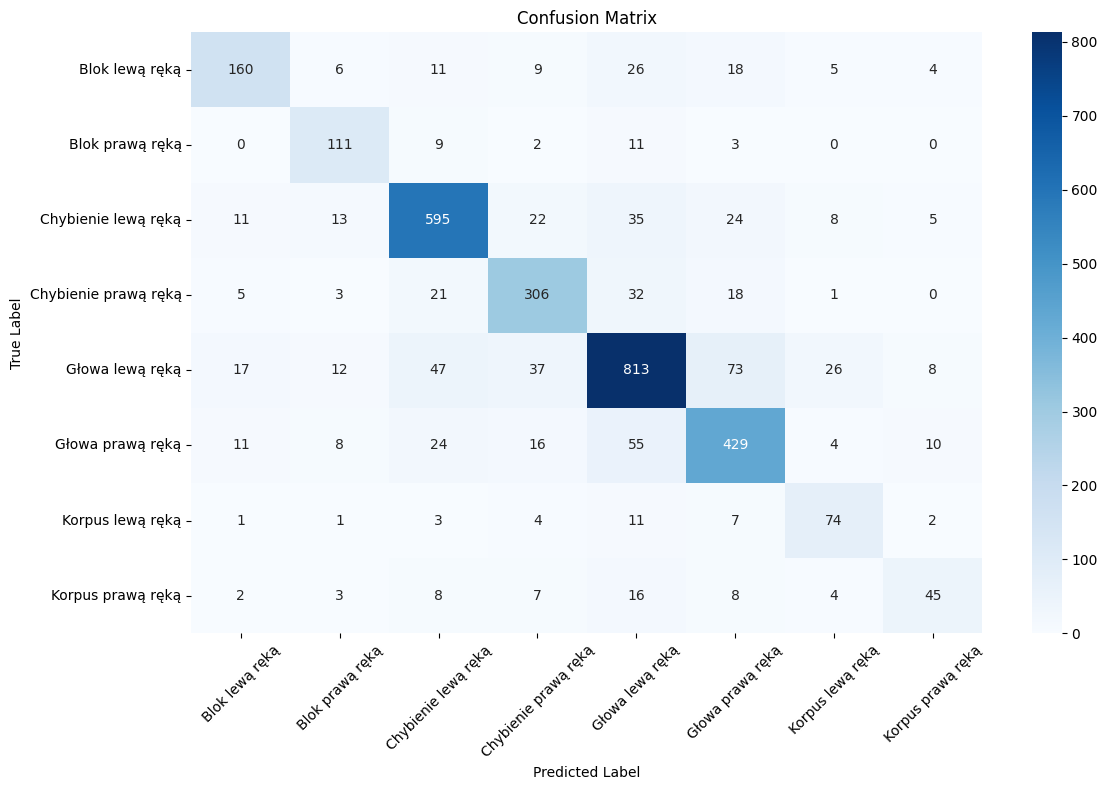


Classification Report:
                      precision    recall  f1-score   support

      Blok lewą ręką       0.77      0.67      0.72       239
     Blok prawą ręką       0.71      0.82      0.76       136
 Chybienie lewą ręką       0.83      0.83      0.83       713
Chybienie prawą ręką       0.76      0.79      0.78       386
     Głowa lewą ręką       0.81      0.79      0.80      1033
    Głowa prawą ręką       0.74      0.77      0.75       557
    Korpus lewą ręką       0.61      0.72      0.66       103
   Korpus prawą ręką       0.61      0.48      0.54        93

            accuracy                           0.78      3260
           macro avg       0.73      0.73      0.73      3260
        weighted avg       0.78      0.78      0.78      3260



In [16]:
def evaluate_model(model, test_loader, device, label_encoder):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs, _ = model(inputs)
            _, predicted = outputs.max(1)

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Create confusion matrix
    cm = confusion_matrix(all_labels, all_preds)
    class_names = label_encoder.classes_

    # Plot confusion matrix
    plt.figure(figsize=(12, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    # Print classification report
    print("\nClassification Report:")
    print(classification_report(all_labels, all_preds,
                              target_names=class_names))

# Load best model and evaluate
model.load_state_dict(torch.load('best_boxing_model.pth'))
evaluate_model(model, test_loader, device, label_encoder)